In [1]:
import os

os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"

import tensorflow as tf
import pandas as pd
import numpy as np

print("TensorFlow:", tf.__version__)

tf.keras.mixed_precision.set_global_policy("float32")

os.environ["CUDA_VISIBLE_DEVICES"] = ""   # hides GPU so TF uses CPU only

print("Running on devices:")
print("GPU:", tf.config.list_physical_devices("GPU"))
print("CPU:", tf.config.list_physical_devices("CPU"))

TensorFlow: 2.20.0
Running on devices:
GPU: []
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-12-09 11:54:27.765803: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-09 11:54:27.765851: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2025-12-09 11:54:27.765860: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2025-12-09 11:54:27.765866: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-09 11:54:27.765873: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: node1712.palmetto.clemson.edu
2025-12-09 11:54:27.765877: I external/local_x

In [2]:
IMG_SIZE   = 256
BATCH      = 4
SPLIT_DIR  = "splits/payne"

def load_pair(img_path, mask_path, img_size=IMG_SIZE):
    # --- load image ---
    x = tf.io.read_file(img_path)
    x = tf.image.decode_image(x, channels=3, expand_animations=False)
    x = tf.image.resize(x, (img_size, img_size))
    x = tf.cast(x, tf.float32) / 255.0

    # --- load mask ---
    y = tf.io.read_file(mask_path)
    y = tf.image.decode_image(y, channels=1, expand_animations=False)
    y = tf.image.resize(y, (img_size, img_size), method="nearest")
    y = tf.cast(y > 127, tf.float32)   # binarize to {0,1}
    return x, y

def dataset_from_csv(csv_path, img_size=IMG_SIZE, batch=BATCH, shuffle=True):
    df = pd.read_csv(csv_path)
    img_paths  = df["image_path"].values
    mask_paths = df["mask_path"].values

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda im, ma: load_pair(im, ma, img_size),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = dataset_from_csv(os.path.join(SPLIT_DIR, "train.csv"), shuffle=True)
val_ds   = dataset_from_csv(os.path.join(SPLIT_DIR, "val.csv"),   shuffle=False)
test_ds  = dataset_from_csv(os.path.join(SPLIT_DIR, "test.csv"),  shuffle=False)

xb, yb = next(iter(train_ds))
payne_train_ds, payne_val_ds, payne_test_ds = train_ds, val_ds, test_ds

In [3]:
from tensorflow.keras import layers, models

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same",
                      use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(f, 3, padding="same",
                      use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inp = layers.Input(input_shape)

    c1 = conv_block(inp, 64);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 128);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 256);  p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 512);  p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 1024)

    u1 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(bn)
    u1 = layers.concatenate([u1, c4])
    u1 = conv_block(u1, 512)

    u2 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(u1)
    u2 = layers.concatenate([u2, c3])
    u2 = conv_block(u2, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(u2)
    u3 = layers.concatenate([u3, c2])
    u3 = conv_block(u3, 128)

    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(u3)
    u4 = layers.concatenate([u4, c1])
    u4 = conv_block(u4, 64)

    out = layers.Conv2D(1, 1, activation="sigmoid")(u4)
    return models.Model(inp, out, name="DeepGlobe_UNet")

unet = build_unet((IMG_SIZE, IMG_SIZE, 3))
unet.summary()

Model: "DeepGlobe_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,728 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,864 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,456 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,049,409 (118.44 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [4]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union        = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    iou          = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

def dice_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom        = tf.reduce_sum(y_true, axis=[1, 2, 3]) + \
                   tf.reduce_sum(y_pred, axis=[1, 2, 3])
    dice         = (2. * intersection + smooth) / (denom + smooth)
    return tf.reduce_mean(dice)

def soft_iou_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union        = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    iou          = (intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(iou)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_iou_loss(y_true, y_pred):
    return 0.5 * bce(y_true, y_pred) + soft_iou_loss(y_true, y_pred)

In [5]:
DEEPGLOBE_BEST = "checkpoints/best.keras" 

unet = build_unet((IMG_SIZE, IMG_SIZE, 3))
unet.load_weights(DEEPGLOBE_BEST)
print("Loaded DeepGlobe best weights from", DEEPGLOBE_BEST)

unet.compile(
    optimizer="adam",
    loss=bce_iou_loss,
    metrics=[iou_metric, dice_metric],
)

Loaded DeepGlobe best weights from checkpoints/best.keras


In [11]:
PAYNE_CKPT_DIR   = "checkpoints/payne_iou"
os.makedirs(PAYNE_CKPT_DIR, exist_ok=True)

ckpt_best_path   = os.path.join(PAYNE_CKPT_DIR, "best_iou.keras")          # full model
ckpt_latest_path = os.path.join(PAYNE_CKPT_DIR, "latest_iou.weights.h5")   # weights only
csv_log_path     = os.path.join(PAYNE_CKPT_DIR, "train_log_iou.csv")

backup = tf.keras.callbacks.BackupAndRestore(
    backup_dir=os.path.join(PAYNE_CKPT_DIR, "backup")
)

ckpt_best = tf.keras.callbacks.ModelCheckpoint(
    filepath=ckpt_best_path,
    monitor="val_iou_metric",
    mode="max",
    save_best_only=True,
    verbose=1,
)

ckpt_latest = tf.keras.callbacks.ModelCheckpoint(
    filepath=ckpt_latest_path,
    save_weights_only=True,
    verbose=1,
)

csv = tf.keras.callbacks.CSVLogger(csv_log_path, append=True)

callbacks = [backup, ckpt_best, ckpt_latest, csv]

In [12]:
initial_epoch = 0
if os.path.exists(ckpt_latest_path):
    print("Resuming from Payne latest checkpoint:", ckpt_latest_path)
    unet.load_weights(ckpt_latest_path)
else:
    print("No Payne IoU checkpoint found – starting fresh from DeepGlobe weights.")

EPOCHS = 5

import os
os.environ["TF_USE_CUDNN"] = "0"   
os.environ["TF_XLA_FLAGS"] = ""     
os.environ["XLA_FLAGS"] = ""

DO_TRAIN = False;
if (DO_TRAIN):
        history = unet.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            initial_epoch=initial_epoch,
            callbacks=callbacks,
        )
else:
    print("Skipping Training")

Resuming from Payne latest checkpoint: checkpoints/payne_iou/latest_iou.weights.h5
Skipping Training


In [13]:
import os
import tensorflow as tf
import numpy as np

payne_best_path = os.path.join(PAYNE_CKPT_DIR, "best_iou.keras")

unet = build_unet((IMG_SIZE, IMG_SIZE, 3))
unet.compile(
    optimizer="adam",
    loss=bce_iou_loss,
    metrics=[iou_metric, dice_metric, "accuracy"],
)

unet.load_weights(payne_best_path)
print("Loaded Payne best weights from:", payne_best_path)

print("\nTest results on PAYNE (Keras metrics):")
test_results = unet.evaluate(payne_test_ds, verbose=1)

test_loss = test_results[0]
test_iou  = test_results[1]
test_dice = test_results[2]
test_acc  = test_results[3]

print(f"\nTest Loss:  {test_loss:.4f}")
print(f"Test IoU:   {test_iou:.4f}")
print(f"Test Dice:  {test_dice:.4f}")
print(f"Test Acc:   {test_acc:.4f}")

/home/zkelias/.conda/envs/mlbd/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 130 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded Payne best weights from: checkpoints/payne_iou/best_iou.keras

Test results on PAYNE (Keras metrics):
244/244 ━━━━━━━━━━━━━━━━━━━━ 1004s 4s/step - accuracy: 0.9748 - dice_metric: 0.6855 - iou_metric: 0.5451 - loss: 0.5201

Test Loss:  0.5201
Test IoU:   0.5451
Test Dice:  0.6855
Test Acc:   0.9748


Using image: data/payne/deepglobe-road-extraction-dataset/train/satImage_036_sat.jpg
Using mask:  data/payne/deepglobe-road-extraction-dataset/train/satImage_036_mask.png


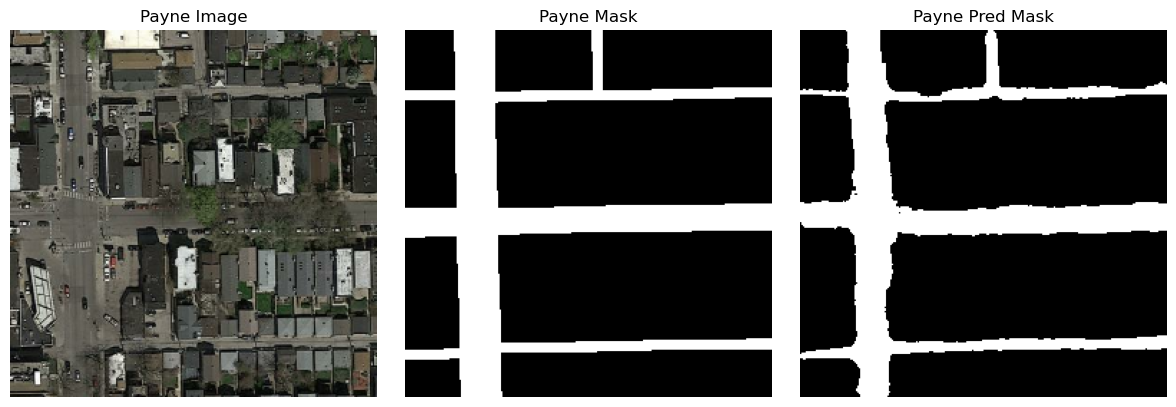

In [20]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import numpy as np
import os
import pandas as pd
import re

test_csv = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

def extract_number(p):
    base = os.path.basename(str(p))
    m = re.search(r"(\d+)", base)
    if m:
        return int(m.group(1))
    return None

nums = test_csv["image_path"].apply(extract_number)

mask_range = (nums >= 1) & (nums <= 100)
filtered = test_csv[mask_range].reset_index(drop=True)


if len(filtered) == 0:
    raise ValueError("No files in test.csv with numbers between 1 and 100 in the name.")

choice = filtered.sample(1).iloc[0]
img_path = choice["image_path"]
mask_path = choice["mask_path"]

print("Using image:", img_path)
print("Using mask: ", mask_path)

img, mtrue = load_pair(img_path, mask_path, img_size=IMG_SIZE)

pred_prob = unet.predict(tf.expand_dims(img, 0), verbose=0)[0, :, :, 0]
pmask = (pred_prob > 0.5).astype(np.float32)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Payne Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Payne Mask")
plt.imshow(mtrue[..., 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Payne Pred Mask")
plt.imshow(pmask, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

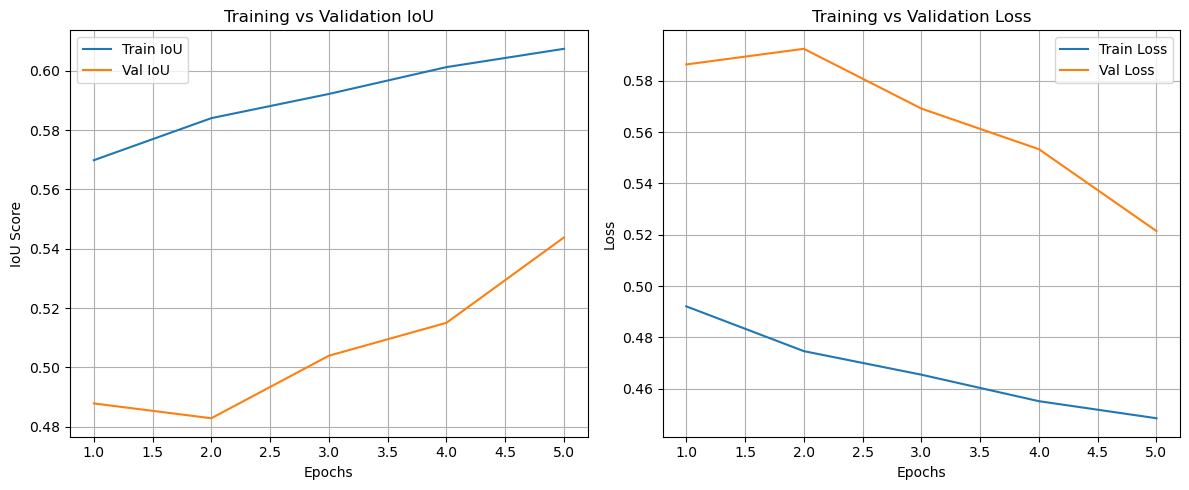

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("checkpoints/payne_iou/train_log_iou.csv")

if "epoch" in log.columns:
    epochs = log["epoch"] + 1
else:
    epochs = range(1, len(log) + 1)

train_iou  = log["iou_metric"]
val_iou    = log["val_iou_metric"]
train_loss = log["loss"]
val_loss   = log["val_loss"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_iou, label="Train IoU")
plt.plot(epochs, val_iou,   label="Val IoU")
plt.title("Training vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU Score")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss,   label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()